# ĐỒ ÁN CUỐI KỲ (FINAL PROJECT)

# 1. Mục tiêu (Objectives)
-----------------------------------

Mục tiêu của bài tập này là sử dụng một công cụ học máy phổ biến, cụ thể là scikit-learn, để nghiên cứu hai yếu tố quan trọng dẫn đến thành công của các ứng dụng học máy, đó là: các chỉ số hiệu suất và tối ưu hóa. Các mục tiêu cụ thể là:

Có khả năng sử dụng các phương pháp phân loại/hồi quy khác nhau được triển khai trong scikit-learn như: kNN, SVM, cây quyết định (decision tree), random forest, AdaBoost, gradient boosting, phân tích biệt thức tuyến tính (LDA), hồi quy logistic, hồi quy tuyến tính, hồi quy k-neighbors, hồi quy Ridge, hồi quy cây quyết định, hồi quy random forest, hồi quy gradient boosting.

So sánh hiệu suất của các phương pháp phân loại/hồi quy khác nhau bằng một số chỉ số phổ biến như: độ chính xác (accuracy), precision, recall, ma trận nhầm lẫn (confusion matrix), AUC dưới đường cong ROC, ... và phân tích kết quả.

So sánh và phân tích các ưu điểm/nhược điểm dựa trên kết quả của các chỉ số hiệu suất khác nhau cho một bài toán hồi quy cụ thể.

-------------------
# Import thư viện

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# Load dữ liệu

In [10]:
df = pd.read_csv("banknote_authentication.csv")

print("Shape:", df.shape)
print("Class distribution:\n", df["class"].value_counts())
df.head()

Shape: (1372, 5)
Class distribution:
 class
0    762
1    610
Name: count, dtype: int64


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


# EDA

In [11]:
df.info()
df.describe()
print("Missing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
Missing values:
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


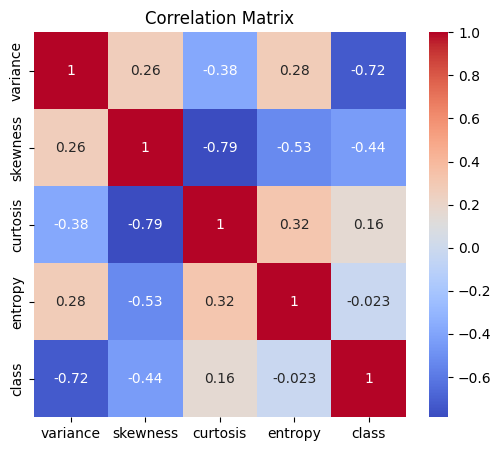

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Xử lý outliers (IQR)

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("class")

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print("After removing outliers:", df.shape)

After removing outliers: (1278, 5)


# Tách dữ liệu

In [14]:
X = df.drop("class", axis=1)
y = df["class"]

# Train/Test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Chuẩn hóa

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODELS

In [17]:
models = {
    "kNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP": MLPClassifier(max_iter=1000),
    "Logistic Regression": LogisticRegression()
}

# Train + đánh giá tất cả model

In [19]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if hasattr(model, "predict_proba"):
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    else:
        auc = 0

    results.append([name, acc, pre, rec, f1, auc])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1,AUC
0,kNN,1.000000,1.000000,1.000000,1.000000,1.000000
2,SVM,1.000000,1.000000,1.000000,1.000000,1.000000
8,MLP,1.000000,1.000000,1.000000,1.000000,1.000000
5,AdaBoost,0.992188,0.987097,0.993506,0.990291,0.998560
6,Gradient Boosting,0.989583,0.974684,1.000000,0.987179,0.999633
4,Random Forest,0.989583,0.974684,1.000000,0.987179,0.999337
9,Logistic Regression,0.979167,0.950617,1.000000,0.974684,1.000000
3,Decision Tree,0.979167,0.974026,0.974026,0.974026,0.978317
7,LDA,0.968750,0.927711,1.000000,0.962500,0.999831
1,Naive Bayes,0.895833,0.875000,0.863636,0.869281,0.960446


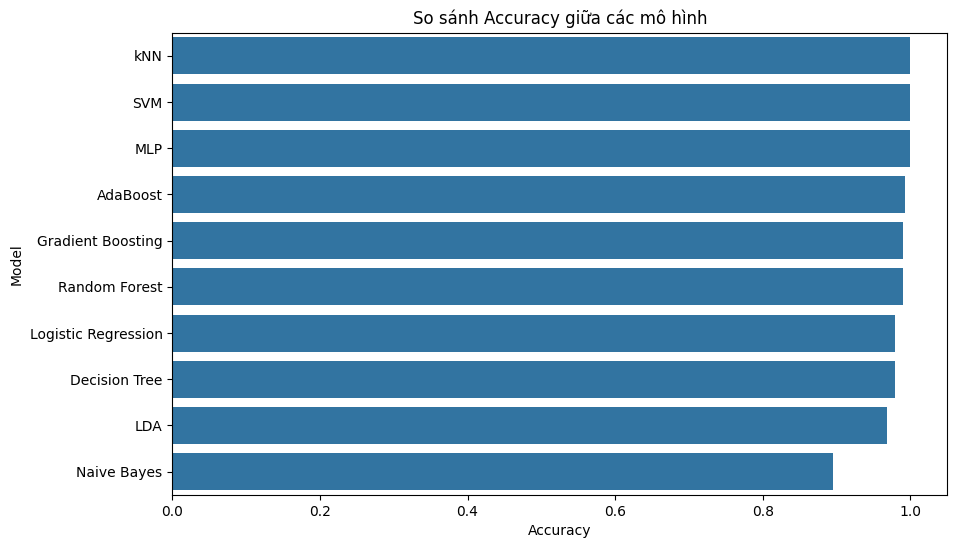

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x="Accuracy", y="Model", data=results_df.sort_values(by="Accuracy", ascending=False))
plt.title("So sánh Accuracy giữa các mô hình")
plt.show()

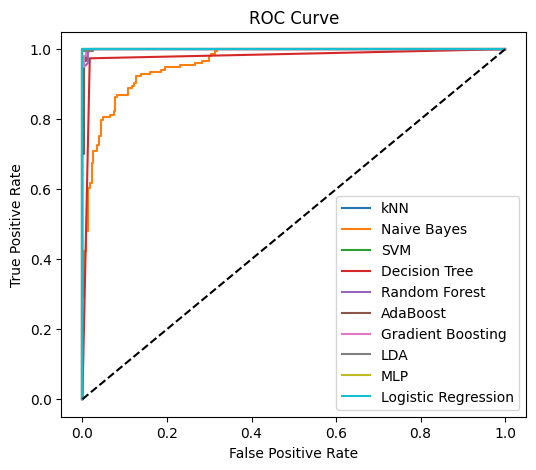

In [21]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(6,5))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Top 2 model theo từng metric

In [30]:
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    print(f"\nTop 2 theo {metric}:")
    print(results_df.sort_values(by=metric, ascending=False).head(2))


Top 2 theo Accuracy:
  Model  Accuracy  Precision  Recall   F1  AUC
0   kNN       1.0        1.0     1.0  1.0  1.0
2   SVM       1.0        1.0     1.0  1.0  1.0

Top 2 theo Precision:
  Model  Accuracy  Precision  Recall   F1  AUC
0   kNN       1.0        1.0     1.0  1.0  1.0
2   SVM       1.0        1.0     1.0  1.0  1.0

Top 2 theo Recall:
  Model  Accuracy  Precision  Recall   F1  AUC
0   kNN       1.0        1.0     1.0  1.0  1.0
2   SVM       1.0        1.0     1.0  1.0  1.0

Top 2 theo F1:
  Model  Accuracy  Precision  Recall   F1  AUC
0   kNN       1.0        1.0     1.0  1.0  1.0
2   SVM       1.0        1.0     1.0  1.0  1.0


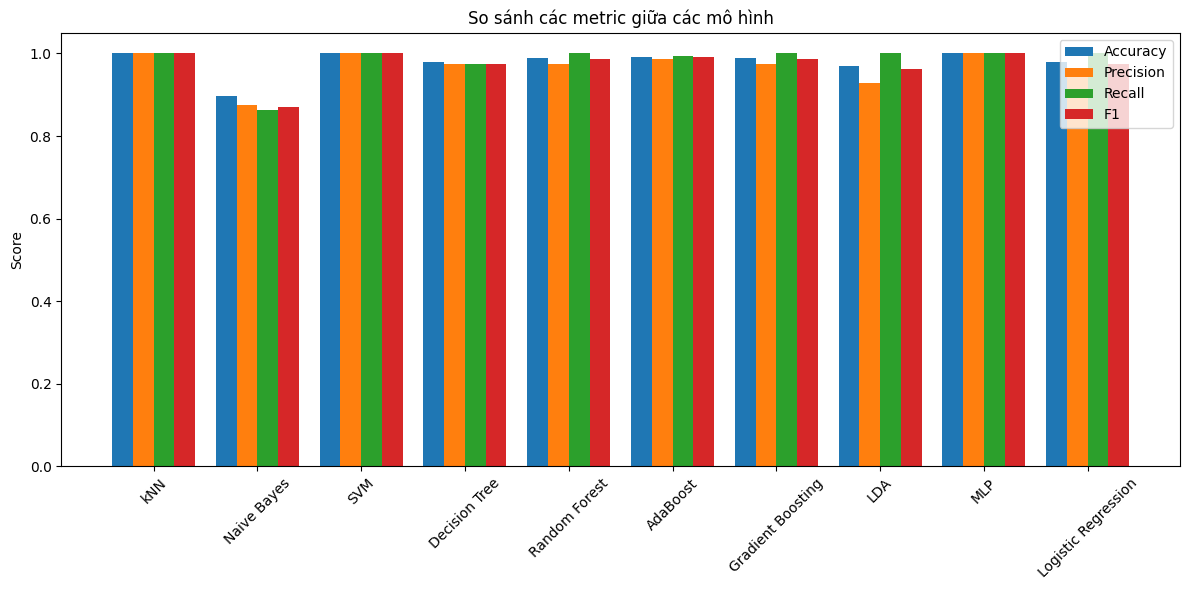

In [32]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(results_df["Model"]))  # vị trí model
width = 0.2

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        results_df[metric],
        width,
        label=metric
    )

plt.xticks(x + width*1.5, results_df["Model"], rotation=45)
plt.ylabel("Score")
plt.title("So sánh các metric giữa các mô hình")
plt.legend()

plt.tight_layout()
plt.show()

# Cross Validation

In [28]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    cv_results.append([name, scores.mean(), scores.std()])

cv_df = pd.DataFrame(cv_results, columns=["Model", "CV Mean Accuracy", "CV Std"])
cv_df.sort_values(by="CV Mean Accuracy", ascending=False)

,Model,CV Mean Accuracy,CV Std
8,MLP,1.000000,0.000000
0,kNN,0.996642,0.002742
2,SVM,0.996642,0.002742
5,AdaBoost,0.993284,0.004194
4,Random Forest,0.992172,0.004466
6,Gradient Boosting,0.991043,0.005723
3,Decision Tree,0.984351,0.006505
9,Logistic Regression,0.983203,0.011230
7,LDA,0.977610,0.009427
1,Naive Bayes,0.875833,0.015607


# Confusion Matrix (model tốt nhất)

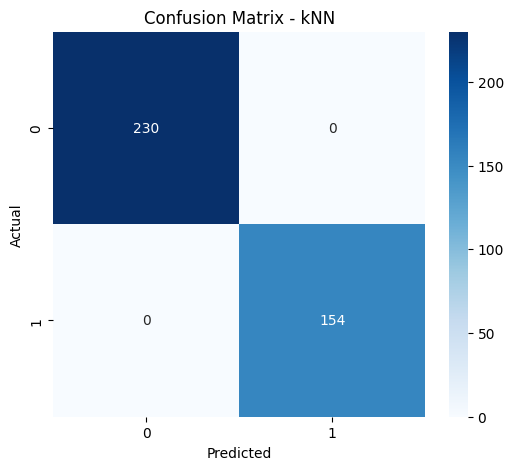

In [22]:
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Pairplot

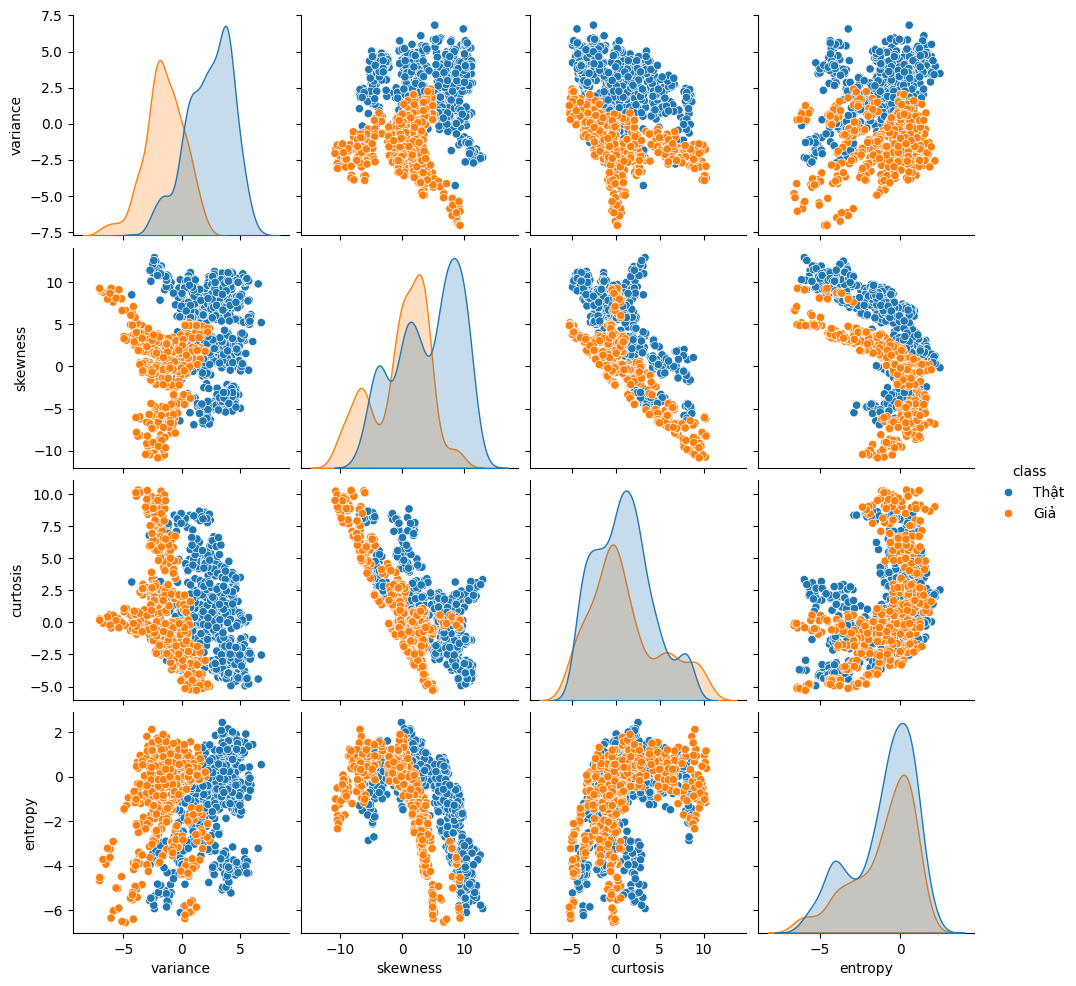

In [23]:
df_plot = df.copy()
df_plot['class'] = df_plot['class'].map({0: 'Thật', 1: 'Giả'})

sns.pairplot(df_plot, hue='class')
plt.show()

# Boxplot

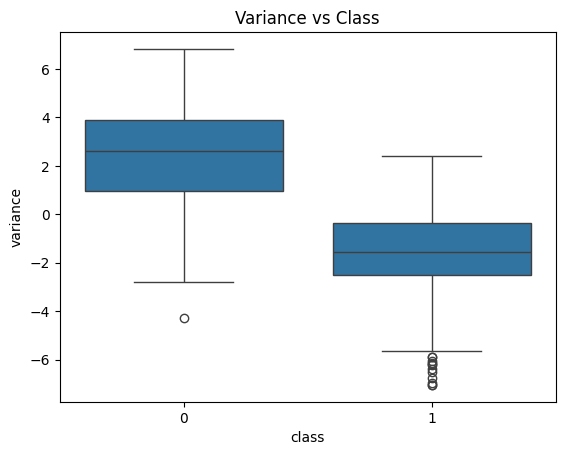

In [24]:
sns.boxplot(x='class', y='variance', data=df)
plt.title("Variance vs Class")
plt.show()

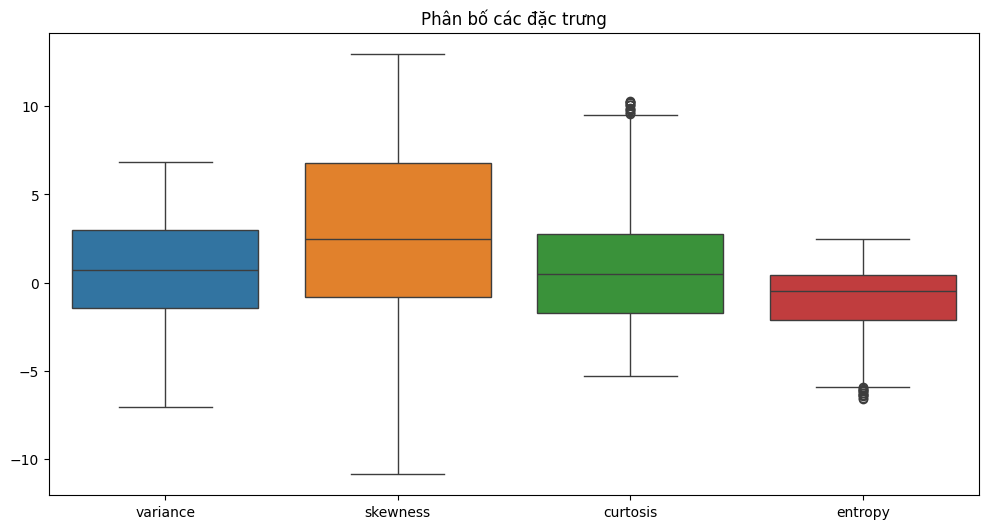

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("class", axis=1))
plt.title("Phân bố các đặc trưng")
plt.show()

# Tuning

In [26]:
params = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'max_depth': None, 'n_estimators': 100}


In [33]:
from sklearn.model_selection import GridSearchCV

params = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(LogisticRegression(), params, cv=5)
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression:", grid_lr.best_params_)

Best Logistic Regression: {'C': 10, 'solver': 'liblinear'}


In [34]:
params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid_knn.fit(X_train, y_train)

print("Best kNN:", grid_knn.best_params_)

Best kNN: {'n_neighbors': 3, 'weights': 'uniform'}


# So sánh trước vs sau tuning

In [35]:
from sklearn.metrics import accuracy_score

# Before tuning
base_model = RandomForestClassifier()
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

# After tuning
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print("Accuracy before tuning:", acc_base)
print("Accuracy after tuning:", acc_tuned)

Accuracy before tuning: 0.9895833333333334
Accuracy after tuning: 0.9895833333333334


-------------------------------
# TỔNG HỢP KẾT QUẢ 

In [ ]:


print("===== 1. THÔNG TIN DỮ LIỆU =====")
print("Số dòng, cột:", df.shape)
print("Phân bố class:\n", df["class"].value_counts())

print("\n===== 2. KẾT QUẢ CÁC MODEL =====")
display(results_df.round(2))

print("\n===== 3. TOP 2 MODEL THEO TỪNG METRIC =====")
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    print(f"\nTop 2 theo {metric}:")
    display(results_df.sort_values(by=metric, ascending=False).head(2).round(2))

print("\n===== 4. CROSS VALIDATION =====")
display(cv_df.round(4))

print("\n===== 5. MODEL TỐT NHẤT =====")
best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]
print(best_model)

print("\n===== 6. CONFUSION MATRIX =====")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n===== 7. TUNING RESULT =====")
print("Random Forest best params:", grid.best_params_)

# Nếu bạn có tuning thêm
try:
    print("Logistic Regression best:", grid_lr.best_params_)
except:
    pass

try:
    print("kNN best:", grid_knn.best_params_)
except:
    pass

===== 1. THÔNG TIN DỮ LIỆU =====
Số dòng, cột: (1278, 5)
Phân bố class:
 class
0    744
1    534
Name: count, dtype: int64

===== 2. KẾT QUẢ CÁC MODEL =====


,Model,Accuracy,Precision,Recall,F1,AUC
0,kNN,1.00,1.00,1.00,1.00,1.00
1,Naive Bayes,0.90,0.88,0.86,0.87,0.96
2,SVM,1.00,1.00,1.00,1.00,1.00
3,Decision Tree,0.98,0.97,0.97,0.97,0.98
4,Random Forest,0.99,0.97,1.00,0.99,1.00
5,AdaBoost,0.99,0.99,0.99,0.99,1.00
6,Gradient Boosting,0.99,0.97,1.00,0.99,1.00
7,LDA,0.97,0.93,1.00,0.96,1.00
8,MLP,1.00,1.00,1.00,1.00,1.00
9,Logistic Regression,0.98,0.95,1.00,0.97,1.00



===== 3. TOP 2 MODEL THEO TỪNG METRIC =====

Top 2 theo Accuracy:


,Model,Accuracy,Precision,Recall,F1,AUC
0,kNN,1.0,1.0,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0,1.0,1.0



Top 2 theo Precision:


...


Top 2 theo F1:


,Model,Accuracy,Precision,Recall,F1,AUC
0,kNN,1.0,1.0,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0,1.0,1.0



===== 4. CROSS VALIDATION =====


,Model,CV Mean Accuracy,CV Std
0,kNN,0.9966,0.0027
1,Naive Bayes,0.8758,0.0156
2,SVM,0.9966,0.0027
3,Decision Tree,0.9844,0.0065
4,Random Forest,0.9922,0.0045
5,AdaBoost,0.9933,0.0042
6,Gradient Boosting,0.9910,0.0057
7,LDA,0.9776,0.0094
8,MLP,1.0000,0.0000
9,Logistic Regression,0.9832,0.0112



===== 5. MODEL TỐT NHẤT =====
Model        kNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1           1.0
AUC          1.0
Name: 0, dtype: object

===== 6. CONFUSION MATRIX =====
[[230   0]
 [  0 154]]

===== 7. TUNING RESULT =====
Random Forest best params: {'max_depth': None, 'n_estimators': 100}
Logistic Regression best: {'C': 10, 'solver': 'liblinear'}
kNN best: {'n_neighbors': 3, 'weights': 'uniform'}
